# 10. Functional Profiling I
To infer the functional potential of the microbial communities, we use PICRUSt2 (Phylogenetic Investigation of Communities by Reconstruction of Unobserved States). PICRUSt2 predicts functional profiles from 16S rRNA gene amplicon data by placing amplicon sequence variants (ASVs) into a reference phylogeny of sequenced genomes and inferring gene content based on evolutionary relationships. As such, PICRUSt2 does not measure functions directly, but estimates the metabolic potential of the community.

PICRUSt2 algorithm:

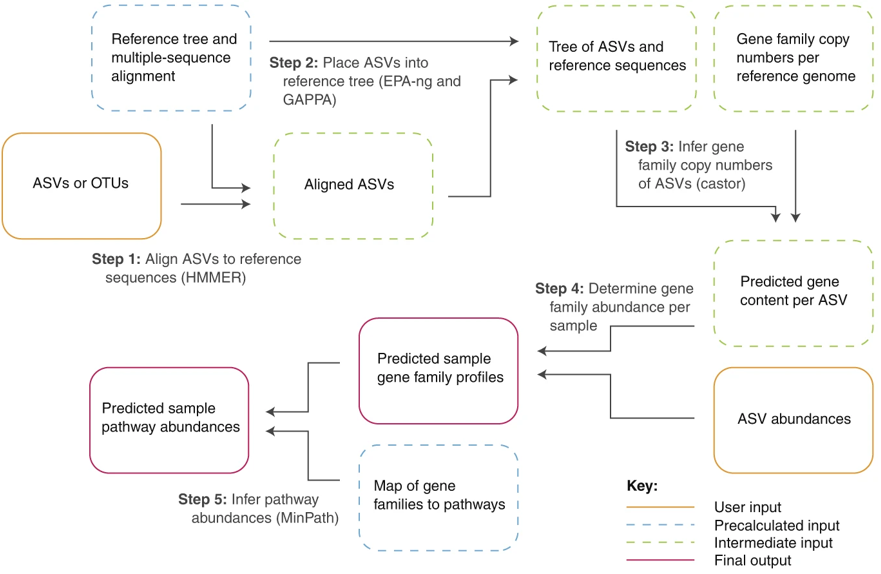

Source: Douglas, G.M., Maffei, V.J., Zaneveld, J.R. et al. PICRUSt2 for prediction of metagenome functions. Nat Biotechnol 38, 685–688 (2020). https://doi.org/10.1038/s41587-020-0548-6

### Notebook Structure
**0.** Setup  
**1.** Install PICRUSt2  
**2.** Prepare the Inputs  
**3.** Run PICRUSt2  
**4.** Analyse the Results  
&nbsp;&nbsp;&nbsp;&nbsp;**4.1** Prediction quality control: NSTI values  
&nbsp;&nbsp;&nbsp;&nbsp;**4.2** Conversion of PICRUSt2 predictions into QIIME 2 artifacts  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; - KEGG Orthologs (KOs)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; - Enzyme Commission (EC) numbers  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; - MetaCyc pathway abundances  
&nbsp;&nbsp;&nbsp;&nbsp;**4.3** Functional beta diversity analysis 
<span style="color:gray">  
&nbsp;&nbsp;&nbsp;&nbsp;**4.4** Functional Differential Abundance Analysis (next notebook)  
    &nbsp;&nbsp;&nbsp;&nbsp;**4.5** Limitations of PICRUSt2 Functional Predictions (next notebook)
</span>  

<div style="border: 2px solid #1f77b4; padding: 10px; border-radius: 6px; background-color: #eaf3fb;">
    
<b> Research questions this notebook answers:</b>
    
- How do the microbiome samples differ between different ages?

- What differences do you see in terms of geolocation?
    
- Did the treatment have an effect on the infant gut microbiome?

</div>

### 0. Setup

In [1]:
# Import all necessary packages
import os
import glob
import shutil
from datetime import datetime
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import qiime2 as q2
from qiime2 import Artifact, Visualization
from skbio.stats.ordination import OrdinationResults
from ipywidgets import Dropdown, FloatSlider, Checkbox, VBox, HBox, IntSlider
import IPython
import re
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

%matplotlib inline

In [2]:
# Set working directory
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts").


In [3]:
# Data directories
raw_data_dir = "../data/raw"
meta_data_dir = "../data/processed/metadata"
denoised_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
diversity_data_dir = "../data/processed/diversity"
phylogeny_data_dir = "../data/processed/phylogeny"
function_preds_data_dir = "../data/processed/function_preds"
# Create the new functional prediction folder

In [4]:
%%bash -s "$function_preds_data_dir"
mkdir -p "$1"

## 1. Install PICRUSt2
To run PICRUSt2 in our JupyterHub setup, we first attempted to use the same conda environment as in the 'Week 10: Shotgun metagenomics – functional annotation and inference' notebook. However, this failed because our DADA2 outputs were created with QIIME 2 version 2025.7.0, while the PICRUSt plugin in that environment used an older framework version. As a result, QIIME2 could not read our .qza files:

`...dada2_rep_seq.qza was created by 'QIIME 2025.7.0'. The currently installed framework cannot interpret archive version '7.0'.`

We then tried creating a new QIIME 2 environment that included a newer, compatible q2-picrust2 version. This also failed due to a system-level glibc incompatibility, which, as far as we understand, can only be resolved by server administrators.

Since we could not identify a functioning way to install the QIIME2-based PICRUSt2 plugin in our JupyterHub environment, we switched to the standalone (non-QIIME2) version of PICRUSt2 instead. 

We install PICRUSt2 manually by cloning the official GitHub repository into a permanent directory, since it would otherwise get deleted every time the server restarts and we would not have access to the reference files.

In [5]:
%%bash
# Installing PICRUSt2 into a custom directory 
# (I got help from ChatGPT for setting up the installation in a specific folder.)

# Folder to store the PICRUSt2 repository and local installation
env_data_dir="../environment"
mkdir -p "$env_data_dir"

# Clone PICRUSt2 if it has not already been cloned
git clone https://github.com/picrust/picrust2.git "$env_data_dir/picrust2"

# Install PICRUSt2 in the current Python environment
pip install -e "$env_data_dir/picrust2"

Cloning into '../environment/picrust2'...
Updating files: 100% (211/211), done.


Obtaining file:///home/jovyan/MicrobiomeAnalysis_TummyTribe/environment/picrust2
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for PICRUSt2 (pyproject.toml): started
  Building editable for PICRUSt2 (pyproject.toml): finished with status 'done'
  Created wheel for PICRUSt2: filename=picrust2-2.6.3-0.editable-py3-none-any.whl size=43680 sha256=7fb1dcc608ae9b206de0a896b0c689dd0e224c429e5dd6d4c152e80fd6437610
  Stored in directory: /tmp/pip-ephem-wheel-cache-cptgwyrw/wheels/4d/7f/83/1dd5e5655f228104fc525799cfe639310b74c76570fae

In [6]:
# Test if its working
!picrust2_pipeline.py -h

usage: picrust2_pipeline.py [-h] -s PATH -i PATH -o PATH [-p PROCESSES]
                            [-t epa-ng|sepp] [-r1 PATH] [-r2 PATH]
                            [--in_traits IN_TRAITS]
                            [--custom_trait_tables_ref1 PATH]
                            [--custom_trait_tables_ref2 PATH]
                            [--marker_gene_table_ref1 PATH]
                            [--marker_gene_table_ref2 PATH]
                            [--pathway_map MAP] [--reaction_func MAP]
                            [--no_pathways] [--regroup_map ID_MAP]
                            [--no_regroup] [--stratified] [--max_nsti FLOAT]
                            [--min_reads INT] [--min_samples INT]
                            [-m {mp,emp_prob,pic,scp,subtree_average}]
                            [-e EDGE_EXPONENT] [--min_align MIN_ALIGN]
                            [--skip_minpath] [--no_gap_fill] [--coverage]
                            [--per_sequence_contrib] [--wide_table]
 

## 2. Prepare the Inputs
For the standalone (non-QIIME2) version of PICRUSt2, we need the representative sequences in FASTA format and the feature table in BIOM format, rather than QIIME 2 artifacts. Therefore, we export these files from our QIIME 2 outputs.

We use the filtered ASV table, where host-derived sequences such as chloroplasts and mitochondria have been removed. This ensures that the input only contains bacterial and archaeal sequences, which are relevant for PICRUSt2 functional prediction. Including host sequences could skew results and artificially increase NSTI values, because PICRUSt2 references only prokaryotic genomes.

In [ ]:
# The filtered ASV table and representative sequences are stored in the taxonomy folder:
# Filtered representative sequences: "$taxonomy_data_dir/dada2_rep_seq_filtered.qza"
# Filtered feature table: "$taxonomy_data_dir/dada2_table_filtered.qza"
# Emergency data restore:
"""
%%bash -s "$taxonomy_data_dir"
wget --progress=bar:force:noscroll \
  -O "$1/dada2_rep_seq_filtered.qza" \
  "https://polybox.ethz.ch/index.php/s/MCkEEBg7d2dmMPZ/download"

wget --progress=bar:force:noscroll \
  -O "$1/dada2_table_filtered.qza" \
  "https://polybox.ethz.ch/index.php/s/TSD6p9td43NZzFy/download"
"""

In [8]:
# Folder for the picrust input files 
input_data_dir=f"{function_preds_data_dir}/picrust_input"

In [9]:
%%bash -s "$input_data_dir" "$taxonomy_data_dir"
# $1 -> input directory (where to put the exported files)
# $2 -> denoised data directory (where the input data QIIME2 artefacts are currently stored)

# Create folder for exported files
mkdir -p "$1"

# Export representative sequences (.fasta)
qiime tools export \
  --input-path "$2/dada2_rep_seq_filtered.qza" \
  --output-path "$1"

# Export ASV table (.biom)
qiime tools export \
  --input-path "$2/dada2_table_filtered.qza" \
  --output-path "$1"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Exported ../data/processed/taxonomy/dada2_rep_seq_filtered.qza as DNASequencesDirectoryFormat to directory ../data/processed/function_preds/picrust_input


/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Exported ../data/processed/taxonomy/dada2_table_filtered.qza as BIOMV210DirFmt to directory ../data/processed/function_preds/picrust_input


## 3. Run PICRUSt2
Running the full PICRUSt2 pipline on JupyterHub results in a memory error. This is not surprising, as the package creators themselves state:

"You will need at least 16 GB of RAM, and the running time may be several hours depending on how many CPUs you can dedicate (and how many samples and sequences are input)." [[PICRUSt2 GitHub Installation]](https://github.com/picrust/picrust2/wiki/Installation)

Consequently, we ran it on Euler. We first attempted to install the PICRUSt2 package on Euler using both Conda and Mamba, but each approach resulted in multiple errors. Therefore, we proceeded with the same manual installation via GitHub as in this Jupyter Notebook (*1. Install PICRUSt2*).

We installed the package with pip on the login node because we don’t have permission to run these commands within a bash script.

1. `git clone https://github.com/picrust/picrust2.git`
2. `cd picrust2`
3. `pip install -e .`

We then had to install several additional packages to prevent the script from terminating:
1. `pip install ete3` 
2. `conda install -c bioconda gappa`
3. `R -e "install.packages('castor', repos='https://cloud.r-project.org/')"`
4. `conda install -c bioconda epa-ng`

The configuration file for this Euler conda environment can be found in the environment folder (*environment/euler_env1.yml*). However, it only includes the conda packages. The packages installed via pip still need to be installed separately.

With the correct environment activated, we can run the full PICRUSt2 functional prediction workflow. This includes phylogenetic placement, hidden-state prediction, and inference of gene family and pathway abundances. 


The parameter choices are based on the guidelines from the [qiime2 picrust2 tutorial](https://github.com/picrust/picrust2/wiki/q2-picrust2-Tutorial):
- `--placement_tool epa-ng:` We use the default EPA-ng placement method, as it is a highly accurate Maximum Likelihood approach.
- `--hsp_method mp:` Following the tutorial’s recommendation, we use the default mp method for hidden-state prediction.
- `--max_nsti 2:` Since our data comes from human stool samples rather than environmental sources, the default NSTI cutoff is appropriate. As the tutorial notes: “In human datasets used for testing PICRUSt2, the only ASVs above this default cut-off were 18S sequences erroneously included in 16S datasets, suggesting this cut-off is highly lenient.” [[qiime2 picrust2 tutorial](https://github.com/picrust/picrust2/wiki/q2-picrust2-Tutorial)]

The code can be found in the *'additional'* folder (in *scripts*) under the name *'10_euler_script_functional_prediction.sh'*. The results were generated on Euler and then transferred to Polybox. From there, they were downloaded into this notebook using wget.

In [ ]:
# This code will result in a memory error, please run the euler script instead
"""
%%bash -s "$input_data_dir" "$function_preds_data_dir"
# $1 -> input directory (where the representative sequences (.fasta) and the ASV table (.biom) are stored)
# $2 -> output directory

# Run standalone PICRUSt2 pipeline
picrust2_pipeline.py \
   -s "$1/dna-sequences.fasta" \
   -i "$1/feature-table.biom" \
   -o "$2/results" \
   -p 3 \
   --placement_tool epa-ng \
   --hsp_method mp \
   --max_nsti 2 \
   --verbose
"""

In [11]:
%%bash -s "$function_preds_data_dir"
# Dowload the results
wget --progress=bar:force:noscroll \
  -O "$1/results.zip" \
  "https://polybox.ethz.ch/index.php/s/t6ojTxjptw6L2tC/download"
unzip -q "$1/results.zip" -d "$1"

--2025-12-15 20:52:22--  https://polybox.ethz.ch/index.php/s/t6ojTxjptw6L2tC/download
Resolving polybox.ethz.ch (polybox.ethz.ch)... 129.132.71.243
Connecting to polybox.ethz.ch (polybox.ethz.ch)|129.132.71.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘../data/processed/function_preds/results.zip’

../data/processed/f     [  <=>               ]  37.23M   117MB/s    in 0.3s    

2025-12-15 20:52:23 (117 MB/s) - ‘../data/processed/function_preds/results.zip’ saved [39039729]



In [12]:
# Filepath to the euler results
results_data_dir = f"{function_preds_data_dir}/results"

## 4. Analyse the Results
PICRUSt2 produces several types of output tables. First, it predicts gene family abundances, including KEGG Orthologs (KOs) and Enzyme Commission (EC) numbers, which represent individual genes or enzyme activities. These gene-level predictions can then be aggregated into higher-level functional units. In addition, PICRUSt2 infers MetaCyc pathway abundances, which summarize gene predictions into complete metabolic pathways. We focus on the Pathway-level outputs, since they are generally more interpretable, less sparse than gene-level tables and also used in the functional beta diversity analysis of the [q2 picrust2 Tutorial](https://github.com/picrust/picrust2/wiki/q2-picrust2-Tutorial). 

### 4.1 Prediction quality control: NSTI values
The accuracy of PICRUSt2 functional predictions depends on how well the detected ASVs are represented by genomes in the reference database. Because our samples originate from the human gut, an environment that is generally well represented in the PICRUSt2 reference genomes, the predictions are expected to be reliable. Nevertheless, we assess prediction quality by examining per-ASV and sample-weighted Nearest Sequenced Taxon Index (NSTI) values, which provide an estimate of how well the detected ASVs are represented in the reference genome database. [[picrust2 Github - Key Limitations](https://github.com/picrust/picrust2/wiki/Key-Limitations)]

NSTI estimates the phylogenetic distance between each ASV and its closest sequenced reference genome, with lower values indicating higher confidence in the predicted functions. By default, PICRUSt2 excludes sequences with very high NSTI values, which may affect some samples more than others. We therefore examine sample-weighted NSTI values to identify potential outlier samples.

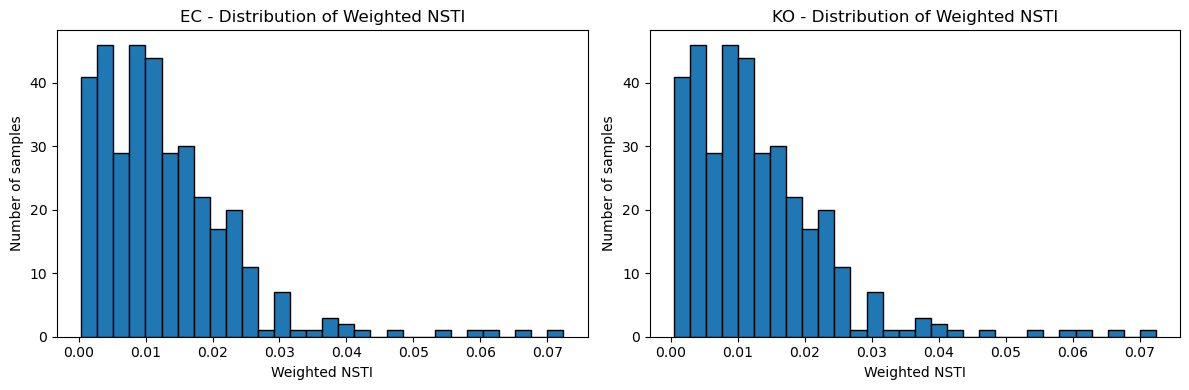

In [13]:
# Load EC and KO weighted NSTI
nsti_ec = pd.read_csv(f"{results_data_dir}/EC_metagenome_out/weighted_nsti.tsv.gz", sep="\t")
nsti_ko = pd.read_csv(f"{results_data_dir}/KO_metagenome_out/weighted_nsti.tsv.gz", sep="\t")

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# EC histogram
axes[0].hist(nsti_ec["weighted_NSTI"], bins=30, edgecolor="black")
axes[0].set_xlabel("Weighted NSTI")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("EC - Distribution of Weighted NSTI")

# KO histogram
axes[1].hist(nsti_ko["weighted_NSTI"], bins=30, edgecolor="black")
axes[1].set_xlabel("Weighted NSTI")
axes[1].set_ylabel("Number of samples")
axes[1].set_title("KO - Distribution of Weighted NSTI")

plt.tight_layout()

As expected, the mean sample-weighted NSTI values (accounting for the relative abundance of ASVs) are very low. In PICRUSt1, weighted NSTI values below 0.06 were considered good, while values above 0.15 were considered high. These thresholds provide a rough point of comparison with other datasets, but a weighted NSTI value above 0.15 does not necessarily imply that the predictions are unreliable [[PICRUSt2 Tutorial](https://github.com/picrust/picrust2/wiki/PICRUSt2-Tutorial-(v2.5.2))]. Since all of our weighted NSTI scores are below 0.08, with most values around 0.01, the detected ASVs are well represented in the reference genome database. This is expected, as PICRUSt2 reference genomes are designed for human gut microbiomes.

                           sequence  16S_rRNA_Count  metadata_NSTI  \
0  a13b44b829a87d8685d3928609420028               3       0.114299   
1  9d4d2a869508788fc4445ad21b7dd96d               8       0.021916   
2  6f340e16f6d0aae34cf53690f1cabd1b               1       0.031079   
3  422593c7eb93b9ba85a0ad0a5575c3c3               1       0.044967   
4  3897db903811dd667c16d8b0e1ea42e9               1       0.379591   

  best_domain closest_reference_genome  
0         bac          GCF_013393365.1  
1         bac          GCF_000025565.1  
2         bac          GCA_001028025.1  
3         bac          GCF_000160755.1  
4         bac          GCF_900130055.1  


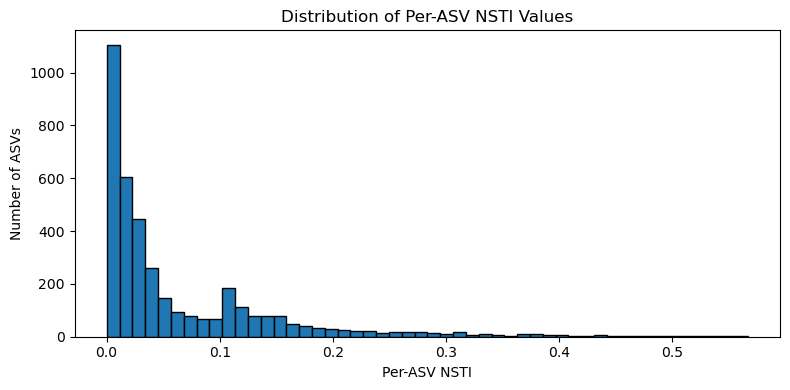

In [14]:
# Load per-ASV NSTI table
per_asv_nsti = pd.read_csv(f"{results_data_dir}/combined_marker_predicted_and_nsti.tsv.gz", sep="\t")
print(per_asv_nsti.head())

# Plot histogram
plt.figure(figsize=(8,4))
plt.hist(per_asv_nsti["metadata_NSTI"], bins=50, edgecolor="black")
plt.xlabel("Per-ASV NSTI")
plt.ylabel("Number of ASVs")
plt.title("Distribution of Per-ASV NSTI Values")
plt.tight_layout()

For the ASVs themselves, the NSTI values are slightly higher, with a median of 0.031 and a maximum of 0.567. Despite this, the per-ASV NSTI values still lie within a reasonable range. For the Human Microbiome Project, the PICRUSt2 authors reported a mean NSTI value of 0.11 (SD = 0.49) and described this as lower than expected, indicating acceptable reference genome coverage [[Douglas et al., 2019](https://www.researchgate.net/publication/333806984_PICRUSt2_An_improved_and_extensible_approach_for_metagenome_inference#pf11)].

### 4.2 Conversion of PICRUSt2 predictions into QIIME 2 artifacts
To enable downstream analyses using QIIME 2, we convert the PICRUSt2-predicted functional profiles into QIIME 2 artifacts.

#### KEGG Orthologs (KOs)
KEGG Orthologs represent groups of homologous genes that perform the same biological function across different organisms. The KO abundance table contains predicted abundances of individual functional genes for each sample and provides a detailed, gene-level view of the predicted functional potential of the microbial community.

In [15]:
# Folder for the KEGG Orthologs results
KO_data_dir=f"{function_preds_data_dir}/KO_results"

In [16]:
%%bash -s "$results_data_dir" "$KO_data_dir"

# Create the results folder for the KEGG Orthologs
mkdir -p "$2"

# Unzip the .tsv file into the KO folder
zcat "$1/KO_metagenome_out/pred_metagenome_unstrat.tsv.gz" > "$2/pred_metagenome_unstrat.tsv"

# Convert TSV to BIOM
biom convert \
  -i "$2/pred_metagenome_unstrat.tsv" \
  -o "$2/pred_metagenome_unstrat.biom" \
  --table-type "OTU table" \
  --to-hdf5

# Import into QIIME2
qiime tools import \
  --input-path "$2/pred_metagenome_unstrat.biom" \
  --type 'FeatureTable[Frequency]' \
  --input-format BIOMV210Format \
  --output-path "$2/KO_table.qza"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Imported ../data/processed/function_preds/KO_results/pred_metagenome_unstrat.biom as BIOMV210Format to ../data/processed/function_preds/KO_results/KO_table.qza


We summarize the KEGG Ortholog (KO) abundance table using QIIME 2 to obtain an overview of gene-level functional abundances across samples.

In [17]:
! qiime feature-table summarize \
   --i-table $KO_data_dir/KO_table.qza \
   --o-visualization $KO_data_dir/KO_table.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/function_preds/KO_results/KO_table.qzv


In [18]:
Visualization.load(f"{KO_data_dir}/KO_table.qzv")

<visualization: Visualization uuid: c70594d7-49e1-40b9-89a5-5771aa8bae25>

#### Enzyme Commission (EC) numbers
Enzyme Commission numbers classify enzymes based on the chemical reactions they catalyze. The EC abundance table contains predicted abundances of enzymatic activities in each sample and summarizes functional potential at the enzyme level, which is often less granular than KOs but more directly linked to biochemical processes.

In [19]:
# Folder for the Enzyme Commission (EC) number results
EC_data_dir=f"{function_preds_data_dir}/EC_results"

In [20]:
%%bash -s "$results_data_dir" "$EC_data_dir"

# Create the results folder for the Enzyme Commission (EC) numbers
mkdir -p "$2"

# Unzip the .tsv file into the EC folder
zcat "$1/EC_metagenome_out/pred_metagenome_unstrat.tsv.gz" > "$2/pred_metagenome_unstrat.tsv"

# Convert TSV to BIOM
biom convert \
  -i "$2/pred_metagenome_unstrat.tsv" \
  -o "$2/pred_metagenome_unstrat.biom" \
  --table-type "OTU table" \
  --to-hdf5

# Import into QIIME2
qiime tools import \
  --input-path "$2/pred_metagenome_unstrat.biom" \
  --type 'FeatureTable[Frequency]' \
  --input-format BIOMV210Format \
  --output-path "$2/EC_table.qza"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Imported ../data/processed/function_preds/EC_results/pred_metagenome_unstrat.biom as BIOMV210Format to ../data/processed/function_preds/EC_results/EC_table.qza


We summarize the Enzyme Commission (EC) abundance table using QIIME 2 to obtain an overview of enzyme-level functional abundances across samples.

In [21]:
! qiime feature-table summarize \
   --i-table $EC_data_dir/EC_table.qza \
   --o-visualization $EC_data_dir/EC_table.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/function_preds/EC_results/EC_table.qzv


In [22]:
Visualization.load(f"{EC_data_dir}/EC_table.qzv")

<visualization: Visualization uuid: b45305df-0848-4a7d-8725-96fa195978cf>

#### MetaCyc pathway abundances
MetaCyc pathways represent complete metabolic pathways reconstructed from sets of individual enzymes and reactions. The pathway abundance table aggregates gene-level predictions into higher-level functional pathways, providing a more interpretable and less sparse representation of the predicted metabolic potential of the microbial community.

In [23]:
# Folder for the pathway results
pathways_data_dir=f"{function_preds_data_dir}/pathways_results"

In [24]:
%%bash -s "$results_data_dir" "$pathways_data_dir"

# Create the results folder for the pathway analysis
mkdir -p "$2"

# Unzip the .tsv file into the pathways folder
zcat "$1/pathways_out/path_abun_unstrat.tsv.gz" > "$2/path_abun_unstrat.tsv"

# Convert TSV to BIOM
biom convert \
  -i "$2/path_abun_unstrat.tsv" \
  -o "$2/path_abun_unstrat.biom" \
  --table-type "OTU table" \
  --to-hdf5

# Import into QIIME2
qiime tools import \
  --input-path "$2/path_abun_unstrat.biom" \
  --type 'FeatureTable[Frequency]' \
  --input-format BIOMV210Format \
  --output-path "$2/pathway_table.qza"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Imported ../data/processed/function_preds/pathways_results/path_abun_unstrat.biom as BIOMV210Format to ../data/processed/function_preds/pathways_results/pathway_table.qza


We summarize the MetaCyc pathway abundance table using QIIME 2 to obtain an overview of pathway abundances across samples.

In [25]:
! qiime feature-table summarize \
   --i-table $pathways_data_dir/pathway_table.qza \
   --o-visualization $pathways_data_dir/pathway_table.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/function_preds/pathways_results/pathway_table.qzv


In [26]:
Visualization.load(f"{pathways_data_dir}/pathway_table.qzv")

<visualization: Visualization uuid: 0983c1c3-1365-4919-ae44-33ea11869448>

### 4.3. Functional beta diversity analysis
To assess differences in predicted functional composition between samples, we perform functional beta diversity analysis using the PICRUSt2-predicted MetaCyc pathway abundance table. We focus on the Pathway-level outputs, since they are generally more interpretable, less sparse than gene-level tables and also used in the functional beta diversity analysis of the [q2 picrust2 Tutorial](https://github.com/picrust/picrust2/wiki/q2-picrust2-Tutorial). 

Before calculating beta diversity, pathway abundances are treated as compositional data. Therefore, we focus on distance metrics that are appropriate for relative abundance data and do not rely on phylogenetic relationships, as the predicted functions themselves are not phylogenetically linked.

We compute Bray–Curtis dissimilarity to capture differences in pathway abundance between samples and Jaccard distance to assess differences in pathway presence and absence. The resulting distance matrices are visualized using Principal Coordinates Analysis (PCoA) to explore functional differences across sample groups.

For functional beta diversity analysis, pathway abundances were rarefied to the minimum observed sample pathway count, following the [q2 picrust2 Tutorial](https://github.com/picrust/picrust2/wiki/q2-picrust2-Tutorial).

We run QIIME2’s core-metrics pipeline to get the Bray–Curtis and Jaccard distance.

In [27]:
print("Running core metrics...")
! qiime diversity core-metrics \
   --i-table $pathways_data_dir/pathway_table.qza \
   --p-sampling-depth 276735 \
   --m-metadata-file $meta_data_dir/metadata_merged.tsv \
   --output-dir $pathways_data_dir/diversity \
   --p-n-jobs 1

Running core metrics...
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/function_preds/pathways_results/diversity/rarefied_table.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/function_preds/pathways_results/diversity/observed_features_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/function_preds/pathways_results/diversity/shannon_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/function_preds/pathways_results/diversity/evenness_vector.qza
Saved DistanceMatrix to: ../data/processed/function_preds/pathways_results/diversity/jaccard_distance_matrix.qza
Saved DistanceMatrix to: ../data/processed/function_preds/pathw

We next examine the PCoA visualizations based on Jaccard and Bray–Curtis distances.

In [28]:
Visualization.load(f"{pathways_data_dir}/diversity/jaccard_emperor.qzv")

<visualization: Visualization uuid: 9d44e1f1-1575-4825-823c-15efa4ee7326>

In [29]:
Visualization.load(f"{pathways_data_dir}/diversity/bray_curtis_emperor.qzv")

<visualization: Visualization uuid: 208b3cca-050b-4dac-93fe-504fceda17b6>

Although no clear clustering is apparent in these plots for any of the metadata categories, we proceed with statistical analysis of functional beta diversity. We use the same approach as in the ASV table diversity analysis, applying PERMANOVA through the adonis2 function in R [[Oksanen et al., 2025](https://search.r-project.org/CRAN/refmans/vegan/html/adonis.html)]. By restricting permutations within host_id, this method accounts for repeated measurements from the same infant, ensuring that observed group-level differences are not driven by individual variation. More details on the original code can be found in notebook 5 ('05_diversity_analysis.ipynb').

In the next cells, we export the QZA distance matrix files so they can be used outside of QIIME 2. Each QZA file is converted into a folder containing a distance-matrix.tsv file, which is required as input for the PERMANOVA analysis in R and allows more flexible statistical modeling than is possible within QIIME 2.

In [30]:
# file path to the functional beta diversity metrics
beta_metrics_dir = f"{pathways_data_dir}/diversity"

In [31]:
beta_distance_matrices = [
    ("jaccard_distance_matrix.qza",            "jaccard_export"),
    ("bray_curtis_distance_matrix.qza",        "bray_curtis_export")
]

print("Exporting QIIME2 distance matrices to TSV...\n")
for qza_name, tsv_name in beta_distance_matrices:
    
    print(f"Converting {qza_name} to {tsv_name}")
    
    # Export feature importance from the raw feature-volatility output
    !qiime tools export \
      --input-path {beta_metrics_dir}/{qza_name} \
      --output-path {beta_metrics_dir}/{tsv_name}

print("\nFinished exporting all distance matrices")

Exporting QIIME2 distance matrices to TSV...

Converting jaccard_distance_matrix.qza to jaccard_export
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/function_preds/pathways_results/diversity/jaccard_distance_matrix.qza as DistanceMatrixDirectoryFormat to directory ../data/processed/function_preds/pathways_results/diversity/jaccard_export
Converting bray_curtis_distance_matrix.qza to bray_curtis_export
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin

Before running PERMANOVA in R, we need to configure the R environment inside Jupyter. In this step, we install the required R packages, enable R support in the notebook, and pass key file paths from Python to R so they can be accessed in later analyses.

In [32]:
# Install required R packages only if they are not already installed
# These packages are needed to run PERMANOVA (adonis2) in R

required_packages = ["r-base", "r-vegan", "r-permute", "rpy2"]

# Get a list of installed conda packages
installed_packages = !conda list
installed_packages = "\n".join(installed_packages)

# Check which required packages are missing
missing_packages = [
    pkg for pkg in required_packages if pkg not in installed_packages
]

# Install only the missing packages
if len(missing_packages) > 0:
    print("Installing missing R packages:", missing_packages)
    !conda install -c conda-forge {" ".join(missing_packages)} -y
else:
    print("All required R packages are already installed.")

All required R packages are already installed.


In [33]:
# Get metadata
metadata  = f"{meta_data_dir}/metadata_merged.tsv"

In [34]:
# Enable R support inside the Jupyter notebook
# This allows us to run R code using the %%R magic
%load_ext rpy2.ipython

# Pass important paths from Python to the R environment
# RUN_DIR points to the main analysis directory
# METADATA points to the sample metadata file
os.environ["BETA_METRICS_DIR"] = beta_metrics_dir 
os.environ["METADATA"] = metadata

# Print the variables to confirm they are set correctly
print("BETA_METRICS_DIR:", os.environ["BETA_METRICS_DIR"])
print("METADATA:", os.environ["METADATA"])

BETA_METRICS_DIR: ../data/processed/function_preds/pathways_results/diversity
METADATA: ../data/processed/metadata/metadata_merged.tsv


####  PERMANOVA (adonis2) with variables that change within infants over time
For the functional beta diversity analysis, we use PERMANOVA (adonis2) [[Oksanen et al., 2025](https://search.r-project.org/CRAN/refmans/vegan/html/adonis.html)] and focus only on metadata variables that change within infants over time, such as age or diet. This produces one PERMANOVA result per variable per distance metric, which we later summarize and compare.

From our ASV-based diversity analysis, we know that PERMANOVA with permutations restricted within host_id cannot properly test variables that are constant within infants (e.g. delivery mode, geographic location, or treatment), because all samples from a given infant fall into the same category. With no meaningful permutations available, PERMANOVA just returns p-values of 1.0.

Therefore, in this analysis we only apply PERMANOVA to changing variables, ensuring that our statistical tests are appropriate for the repeated-measures design of the study.

In [35]:
%%R
library(vegan)

# choose one of the modes here
mode <- "restricted"   # Options: "restricted" (permutation-based within host-id) or "covariate"

run_adonis2 <- function(dm, meta, group_col,
                        mode = c("restricted", "covariate"),
                        host_col = "host_id",
                        permutations = 999,
                        by = "margin") {

    # Choose between the two supported options
    mode <- match.arg(mode)

    # Check that columns exist
    if (!group_col %in% colnames(meta)) {
        stop(paste("Column", group_col, "not found in metadata."))
    }
    if (!host_col %in% colnames(meta)) {
        stop(paste("Host ID column", host_col, "not found in metadata."))
    }

    # Option 1: Restricted permutations
    #
    # Model:    dm ~ group_col
    # Permute:  within each host
    
    if (mode == "restricted") {

        formula_str <- paste("dm ~", group_col)
        fm <- as.formula(formula_str)

        res <- adonis2(
            fm,
            data = meta,
            permutations = permutations,
            by = by,
            strata = meta[[host_col]]   # apply within-host permutations
        )

        attr(res, "mode") <- "restricted"
    }

    # Option 2: Host ID as a covariate
    #
    # Model:    dm ~ group_col + host_id
    # Permute:  across all samples

    if (mode == "covariate") {

        formula_str <- paste("dm ~", group_col, "+", host_col)
        fm <- as.formula(formula_str)

        res <- adonis2(
            fm,
            data = meta,
            permutations = permutations,
            by = by
        )

        attr(res, "mode") <- "covariate"
    }

    return(res)
}

# Metadata variables to test
group_columns <- c("age_months", "diet_milk", "diet_weaning")

# Distance metric folders
beta_distance_folders <- list(
    jaccard            = "jaccard_export",
    bray_curtis        = "bray_curtis_export"
)

# Paths passed from Python
metadata_path <- Sys.getenv("METADATA")
run_dir <- Sys.getenv("BETA_METRICS_DIR")

if (metadata_path == "" || run_dir == "") {
    stop("ERROR: METADATA or RUN_DIR were not set from Python.")
}

# Load metadata
meta <- read.table(metadata_path, sep="\t", header=TRUE, row.names=1)

if (!("host_id" %in% colnames(meta))) {
    stop("ERROR: metadata must contain a 'host_id' column.")
}

# Create output folder
output_dir <- file.path(run_dir, paste0("adonis2_mode_", mode))
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

cat(" Running PERMANOVA\n")
cat(" Mode:", mode, "\n")
cat(" Saving results to:", output_dir, "\n")


# Main loop over all distance matrices
for (prefix in names(beta_distance_folders)) {

    cat("Processing metric:", prefix, "\n")

    folder_path <- file.path(run_dir, beta_distance_folders[[prefix]])
    dm_file <- file.path(folder_path, "distance-matrix.tsv")

    if (!file.exists(dm_file)) {
        cat("  Skipped: no distance matrix found.\n\n")
        next
    }

    # Load distance matrix
    dm_df <- read.table(dm_file, sep="\t", header=TRUE, row.names=1, check.names=FALSE)

    # Ensure sample IDs match metadata
    common_ids <- intersect(rownames(dm_df), rownames(meta))

    if (length(common_ids) < 3) {
        cat("  Skipped: too few overlapping samples.\n\n")
        next
    }

    # Subset both matrices
    dm <- as.dist(as.matrix(dm_df[common_ids, common_ids]))
    meta_sub <- meta[common_ids, ]


    # Loop over each metadata variable
    for (group_col in group_columns) {

        if (!group_col %in% colnames(meta_sub)) {
            cat("  Skipping variable:", group_col, "(not in metadata)\n")
            next
        }

        # Run PERMANOVA using the chosen mode
        res <- run_adonis2(
            dm       = dm,
            meta     = meta_sub,
            group_col = group_col,
            mode      = mode,
            host_col  = "host_id",
            permutations = 999
        )

        # Output filename
        out_file <- file.path(
            output_dir,
            paste0(prefix, "_adonis2_", mode, "_", group_col, ".tsv")
        )

        write.table(
            as.data.frame(res),
            file = out_file,
            sep = "\t", quote = FALSE,
            col.names = NA
        )

        cat("  Saved:", out_file, "\n")
    }

    cat("\n")
}

# save the mode that we used for use in file path in the next python code cell
Sys.setenv(PERMANOVA_MODE = mode)

cat("Completed PERMANOVA in mode:", mode, "\n")

R[write to console]: Loading required package: permute

R[write to console]: Loading required package: lattice

R[write to console]: This is vegan 2.6-8



 Running PERMANOVA
 Mode: restricted 
 Saving results to: ../data/processed/function_preds/pathways_results/diversity/adonis2_mode_restricted 
Processing metric: jaccard 
  Saved: ../data/processed/function_preds/pathways_results/diversity/adonis2_mode_restricted/jaccard_adonis2_restricted_age_months.tsv 
  Saved: ../data/processed/function_preds/pathways_results/diversity/adonis2_mode_restricted/jaccard_adonis2_restricted_diet_milk.tsv 
  Saved: ../data/processed/function_preds/pathways_results/diversity/adonis2_mode_restricted/jaccard_adonis2_restricted_diet_weaning.tsv 

Processing metric: bray_curtis 
  Saved: ../data/processed/function_preds/pathways_results/diversity/adonis2_mode_restricted/bray_curtis_adonis2_restricted_age_months.tsv 
  Saved: ../data/processed/function_preds/pathways_results/diversity/adonis2_mode_restricted/bray_curtis_adonis2_restricted_diet_milk.tsv 
  Saved: ../data/processed/function_preds/pathways_results/diversity/adonis2_mode_restricted/bray_curtis_ado

Each PERMANOVA test produces a separate TSV file, with one file per metadata variable and distance metric. To make the results easier to compare and interpret, we collect all of these files and merge them into a single summary table in the next cell.

In [36]:
# Read all PERMANOVA result files produced by adonis2
# Each file corresponds to one metadata variable and one distance metric

mode = os.getenv("PERMANOVA_MODE", "restricted")
print("Using PERMANOVA mode:", mode)

results_dir = f"{beta_metrics_dir}/adonis2_mode_{mode}"
print("Results directory:", results_dir)

rows = []

# Loop over all result files in the output directory
for file in os.listdir(results_dir):
    if file.endswith(".tsv"):

        # Extract distance metric and metadata variable from the filename
        m = re.match(rf"(.*?)_adonis2_{mode}_(.*?)\.tsv$", file)
        if not m:
            continue

        dist_metric = m.group(1)
        meta_var = m.group(2)

        # Load the PERMANOVA results table
        df = pd.read_csv(os.path.join(results_dir, file), sep="\t", index_col=0)

        # Skip files where the expected metadata variable is not present
        if meta_var not in df.index:
            continue

        # Extract statistics for the metadata variable of interest
        stats = df.loc[meta_var]

        # Store relevant values in a list of rows
        rows.append({
            "metadata_variable": meta_var,
            "metric": dist_metric,
            "F_value": stats["F"],
            "R2": stats["R2"],
            "p_value": stats["Pr(>F)"],
        })

# Combine all collected rows into a single dataframe
summary = pd.DataFrame(rows)


# Convert metadata variable names into more readable labels
summary["metadata_variable"] = (
    summary["metadata_variable"]
    .str.replace("_", " ")
    .str.title()
    .str.replace("Geo Location Name", "Geo Location")
)

# Replace raw distance metric names with nicer labels
metric_rename = {
    "weighted_unifrac": "Weighted UniFrac",
    "unweighted_unifrac": "Unweighted UniFrac",
    "bray_curtis": "Bray-Curtis",
    "jaccard": "Jaccard"
}
summary["metric"] = summary["metric"].replace(metric_rename)

# Add significance stars based on p-values
def stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

summary["sig"] = summary["p_value"].apply(stars)

# Round numeric values for cleaner presentation
summary["F_value"] = summary["F_value"].round(3)
summary["R2"] = summary["R2"].round(4)
summary["p_value"] = summary["p_value"].round(3)

# Define a logical order for metadata variables
sort_order = [
    "Age Months",
    "Diet Milk",
    "Diet Weaning",
]
summary["metadata_variable"] = pd.Categorical(
    summary["metadata_variable"],
    categories=sort_order,
    ordered=True
)

# Sort the final summary table
summary_global = summary.sort_values(["metadata_variable", "metric"])

# Display the summarized PERMANOVA results
print("Final summarized PERMANOVA results:")
summary_global

Using PERMANOVA mode: restricted
Results directory: ../data/processed/function_preds/pathways_results/diversity/adonis2_mode_restricted
Final summarized PERMANOVA results:


,metadata_variable,metric,F_value,R2,p_value,sig
3,Age Months,Bray-Curtis,10.869,0.0298,0.001,**
4,Age Months,Jaccard,11.448,0.0313,0.001,**
0,Diet Milk,Bray-Curtis,5.370,0.0438,0.017,*
2,Diet Milk,Jaccard,3.509,0.0290,0.001,**
1,Diet Weaning,Bray-Curtis,6.469,0.0354,0.008,**
5,Diet Weaning,Jaccard,4.600,0.0254,0.005,**


The PERMANOVA results indicate that functional beta diversity of the predicted pathways is significantly associated with variables that change within infants over time.

- **Age (Months)** shows the strongest effect on both Bray-Curtis and Jaccard distances, with high F values and very low p-values (p = 0.001), suggesting that age explains a meaningful portion of the variation in microbiome function.

- **Diet Milk** also has a significant effect, particularly for Jaccard (p = 0.001) and Bray-Curtis (p = 0.017), indicating that the type of milk consumed influences the functional composition of the gut microbiome.

- **Diet Weaning** is similarly significant for both distance metrics (p = 0.005 for Jaccard and 0.008 for Bray-Curtis), reflecting changes in microbiome function as infants transition to solid foods.

Overall, these results show that the functional composition of the gut microbiome changes over time and with feeding patterns, with age having the largest impact.

#### PERMANOVA (adonis2) on individual age groups for variables that remain constant within infants
In this section, we test metadata variables that do not change within infants, such as delivery mode, geographic location, and treatment exposure. To avoid issues with repeated measurements, we run PERMANOVA separately for each age group and include only one sample per infant at a time. By analyzing each age group independently and removing duplicate samples per host, we can use adonis2 while maintaining a valid statistical design. This allows us to evaluate time-invariant variables in a way that is consistent with the functional beta diversity analyses performed earlier.

In [37]:
%%R

# Clear the R environment to avoid conflicts from previous cells
rm(list = ls())

library(vegan)

# Metadata variables that do not change within infants
static_vars <- c(
    "geo_location_name",
    "delivery_mode",
    "treatment_exposure"
)

# Age groups to analyze separately
ages <- c(4, 7, 10)

# Location of exported distance matrices
beta_distance_folders <- list(
    jaccard            = "jaccard_export",
    bray_curtis        = "bray_curtis_export"
)

# Paths passed from Python
metadata_path <- Sys.getenv("METADATA")
run_dir       <- Sys.getenv("BETA_METRICS_DIR")

if (metadata_path == "" || run_dir == "") {
    stop("ERROR: METADATA or RUN_DIR not set from Python.")
}

# Load metadata
meta <- read.table(metadata_path, sep = "\t", header = TRUE, row.names = 1)

if (!("host_id" %in% colnames(meta))) {
    stop("ERROR: metadata must contain a 'host_id' column.")
}

# Output directory for age-stratified PERMANOVA results
static_dir <- file.path(run_dir, "adonis2_static_vars")
dir.create(static_dir, recursive = TRUE, showWarnings = FALSE)

cat("Running PERMANOVA for static variables by age group\n\n")

# Loop over beta diversity distance metrics
for (prefix in names(beta_distance_folders)) {

    cat("Processing metric:", prefix, "\n")

    dm_path <- file.path(
        run_dir,
        beta_distance_folders[[prefix]],
        "distance-matrix.tsv"
    )

    if (!file.exists(dm_path)) {
        cat("  Distance matrix not found, skipping\n\n")
        next
    }

    # Load distance matrix
    dm_df <- read.table(
        dm_path, sep = "\t", header = TRUE,
        row.names = 1, check.names = FALSE
    )
    dm <- as.matrix(dm_df)

    # Loop over age groups
    for (age in ages) {

        cat("  Age:", age, "months\n")

        # Subset metadata to one age group
        meta_age <- subset(meta, age_months == age)

        # Keep only one sample per infant (to adjust for multiple samples for one host at one time point)
        meta_age <- meta_age[!duplicated(meta_age[, c("host_id", "age_months")]), ]

        # Match samples between metadata and distance matrix
        ids <- intersect(rownames(meta_age), rownames(dm))

        if (length(ids) < 3) {
            cat("    Too few samples after filtering, skipping\n")
            next
        }

        meta_age <- meta_age[ids, ]
        dm_sub <- as.dist(dm[ids, ids])

        # Loop over static metadata variables
        for (var in static_vars) {

            if (!(var %in% colnames(meta_age))) {
                cat("    Variable not found:", var, "\n")
                next
            }

            # Skip variables with no group variation
            if (length(unique(meta_age[[var]])) < 2) {
                cat("    Only one group for", var, ", skipping\n")
                next
            }

            # Construct PERMANOVA formula
            formula <- as.formula(paste("dm_sub ~", var))

            # Run PERMANOVA
            res <- adonis2(formula, data = meta_age)

            # Save result
            out_file <- file.path(
                static_dir,
                paste0(prefix, "_age", age, "_", var, "_adonis2.tsv")
            )

            write.table(
                as.data.frame(res),
                out_file,
                sep = "\t", quote = FALSE,
                col.names = NA
            )

            cat("    Saved:", out_file, "\n")
        }
    }

    cat("\n")
}

cat("Completed age-stratified PERMANOVA analysis\n")

Running PERMANOVA for static variables by age group

Processing metric: jaccard 
  Age: 4 months
    Saved: ../data/processed/function_preds/pathways_results/diversity/adonis2_static_vars/jaccard_age4_geo_location_name_adonis2.tsv 
    Saved: ../data/processed/function_preds/pathways_results/diversity/adonis2_static_vars/jaccard_age4_delivery_mode_adonis2.tsv 
    Saved: ../data/processed/function_preds/pathways_results/diversity/adonis2_static_vars/jaccard_age4_treatment_exposure_adonis2.tsv 
  Age: 7 months
    Saved: ../data/processed/function_preds/pathways_results/diversity/adonis2_static_vars/jaccard_age7_geo_location_name_adonis2.tsv 
    Saved: ../data/processed/function_preds/pathways_results/diversity/adonis2_static_vars/jaccard_age7_delivery_mode_adonis2.tsv 
    Saved: ../data/processed/function_preds/pathways_results/diversity/adonis2_static_vars/jaccard_age7_treatment_exposure_adonis2.tsv 
  Age: 10 months
    Saved: ../data/processed/function_preds/pathways_results/diver

In this step, we collect the PERMANOVA results generated for the age-stratified analyses of static metadata variables. All result files are parsed and combined into a single summary table, which allows us to compare effects across age groups, distance metrics, and metadata variables.

In [38]:
# Read PERMANOVA result files for static variables
# Each file corresponds to one distance metric, one age group, and one metadata variable

results_dir = f"{beta_metrics_dir}/adonis2_static_vars"
print("Reading PERMANOVA files from:", results_dir)

rows = []

# Filename pattern:
# <metric>_age<age>_<metadata_variable>_adonis2.tsv
pattern = r"^(.*?)_age(\d+)_(.*?)_adonis2\.tsv$"

for file in os.listdir(results_dir):
    if not file.endswith(".tsv"):
        continue

    match = re.match(pattern, file)
    if not match:
        continue

    # Extract information from the filename
    dist_metric = match.group(1)
    age = int(match.group(2))
    meta_var = match.group(3)

    # Load the PERMANOVA result table
    df = pd.read_csv(os.path.join(results_dir, file), sep="\t", index_col=0)

    # Always use the "Model" row, which contains the overall test result
    if "Model" not in df.index:
        print(f"File {file} does not contain a 'Model' row, skipping.")
        continue

    stats = df.loc["Model"]

    # Store the relevant statistics
    rows.append({
        "Age": age,
        "metadata_variable": meta_var,
        "metric": dist_metric,
        "F_value": stats["F"],
        "R2": stats["R2"],
        "p_value": stats["Pr(>F)"],
    })

# Combine all parsed results into a single dataframe
summary = pd.DataFrame(rows)

if summary.empty:
    raise ValueError("No PERMANOVA results were parsed. Check file names and structure.")

# Convert metadata variable names into more readable labels
summary["metadata_variable"] = (
    summary["metadata_variable"]
    .str.replace("_", " ")
    .str.title()
    .str.replace("Geo Location Name", "Geo Location")
)

# Replace raw distance metric names with nicer labels
metric_rename = {
    "weighted_unifrac": "Weighted UniFrac",
    "unweighted_unifrac": "Unweighted UniFrac",
    "bray_curtis": "Bray-Curtis",
    "jaccard": "Jaccard"
}
summary["metric"] = summary["metric"].replace(metric_rename)

# Add significance stars based on p-values
def stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

summary["sig"] = summary["p_value"].apply(stars)

# Round numeric values for cleaner display
summary["F_value"] = summary["F_value"].round(3)
summary["R2"] = summary["R2"].round(4)
summary["p_value"] = summary["p_value"].round(3)

# Sort the table by metadata variable, age, and distance metric
summary_static = summary.sort_values(
    ["metadata_variable", "Age", "metric"]
)

# Display the final summary table
print("Final summarized static-variable PERMANOVA results:")
summary_static

Reading PERMANOVA files from: ../data/processed/function_preds/pathways_results/diversity/adonis2_static_vars
Final summarized static-variable PERMANOVA results:


,Age,metadata_variable,metric,F_value,R2,p_value,sig
2,4,Delivery Mode,Bray-Curtis,2.331,0.0219,0.044,*
15,4,Delivery Mode,Jaccard,2.602,0.0244,0.014,*
4,7,Delivery Mode,Bray-Curtis,2.278,0.0196,0.044,*
9,7,Delivery Mode,Jaccard,1.062,0.0092,0.372,
17,10,Delivery Mode,Bray-Curtis,1.013,0.0086,0.384,
5,10,Delivery Mode,Jaccard,0.993,0.0084,0.369,
1,4,Geo Location,Bray-Curtis,4.089,0.0736,0.003,**
8,4,Geo Location,Jaccard,5.118,0.0904,0.001,**
13,7,Geo Location,Bray-Curtis,9.447,0.1432,0.001,**
6,7,Geo Location,Jaccard,4.701,0.0768,0.001,**


After stratifying by age, we can now evaluate the effects of variables that are constant within infants.

- **Delivery Mode** shows a significant effect at 4 months for both Bray-Curtis (p = 0.044) and Jaccard (p = 0.014), and a smaller effect at 7 months for Bray-Curtis (p = 0.044). At 10 months, however, the effect is not significant. This suggests that the mode of delivery may influence early functional microbiome composition, but its effect diminishes as infants grow.

- **Geographic Location** has consistently strong and significant effects across all ages and both distance metrics. The F and R² values are higher than for other variables, indicating that the location of the infant explains a substantial portion of variation in functional beta diversity. This suggests that environmental or regional factors strongly shape microbiome function.

- **Treatment Exposure** shows modest effects. At 4 and 7 months, there are significant associations for both Bray-Curtis and Jaccard metrics, but by 10 months, the effect is no longer significant. This implies that interventions or exposures may influence functional microbiome composition early on, but the impact fades over time. However, this interpretation is limited by the fact that we don't have details about the specific treatment the infants received.

Overall, stratifying by age allows us to detect the influence of constant variables that PERMANOVA cannot handle in the longitudinal setup.

#### Visualization of diversity results 
First, we copy the plotting functions from notebook 5 to visualize our results.

In [39]:
# Load the sample metadata table
metadata_df = pd.read_csv(metadata, sep="\t")

# Set the sample ID column as the index
# This allows us to easily match metadata to PCoA coordinates by sample ID
metadata_df = metadata_df.set_index("id")

In [40]:
# Convert the main PERMANOVA summary table into a lookup dictionary
# This will be used to annotate PCoA plots with F values, R2 values, and p-values

permanova_lookup = {}

for _, row in summary_global.iterrows():

    # Extract metadata variable name and distance metric
    clean_var = row["metadata_variable"].strip()
    clean_metric = row["metric"].strip()

    # Use (variable, metric) as the lookup key
    key = (clean_var, clean_metric)

    # Store the relevant PERMANOVA statistics
    permanova_lookup[key] = {
        "F": row["F_value"],
        "R2": row["R2"],
        "p": row["p_value"],
        "sig": row["sig"],
    }


# Convert the age-stratified PERMANOVA summary table into a separate lookup
# This lookup stores results for static variables across different age groups
static_lookup = {}

for _, row in summary_static.iterrows():

    # Use (variable, metric) as the lookup key
    key = (row["metadata_variable"], row["metric"])

    # Initialize a list for this key if it does not yet exist
    if key not in static_lookup:
        static_lookup[key] = []

    # Append the results for the current age group
    static_lookup[key].append({
        "Age": row["Age"],
        "F": row["F_value"],
        "R2": row["R2"],
        "p": row["p_value"],
        "sig": row["sig"]
    })

In [41]:
# Helper function to draw ellipses

def add_confidence_ellipse(ax, x, y, color, alpha=0.20):
    """Draw a 1 SD covariance ellipse for a group of PCoA points."""

    # Need at least 3 points to compute covariance
    if len(x) < 3:
        return

    x = x.astype(float)
    y = y.astype(float)

    # Covariance matrix -> eigenvalues/vectors describe the ellipse
    cov = np.cov(x, y)
    mean_x, mean_y = np.mean(x), np.mean(y)
    eigvals, eigvecs = np.linalg.eigh(cov)

    # Sort eigenvalues descending
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Width and height correspond to 1 SD (scaled)
    width = 2 * np.sqrt(eigvals[0])
    height = 2 * np.sqrt(eigvals[1])

    # Compute rotation angle
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    ellipse = Ellipse(
        (mean_x, mean_y),
        width,
        height,
        angle=angle,
        facecolor=color,
        edgecolor=color,
        alpha=alpha,
        linewidth=1.4
    )
    ax.add_patch(ellipse)

In [42]:
# Load the pcoa artifact

def load_pcoa(metric_file, metadata_df, column):
    """
    Load a QIIME2 PCoA artifact, extract PC1 and PC2, merge with metadata,
    and return both the coordinates and the variance explained.
    """

    pcoa_art = Artifact.load(metric_file)
    pcoa = pcoa_art.view(OrdinationResults)

    coords = pcoa.samples.copy()
    coords.index.name = "SampleID"

    # Keep only PC1 and PC2
    coords = coords.iloc[:, :2]
    coords.columns = ["PC1", "PC2"]

    var_exp = pcoa.proportion_explained.iloc[:2].values

    # Merge with metadata
    df = coords.join(metadata_df[column], how="inner")
    df = df.dropna(subset=[column])
    df[column] = df[column].astype(str).str.strip().astype("category")

    return df, var_exp

In [43]:
# Plot a single pcoa plot

def plot_single_pcoa(ax, df, var_exp, column, metric_name, centroid_marker="X"):
    """Plot one PCoA panel including points, ellipses, and centroids."""

    groups = df[column].cat.categories.tolist()

    # A simple reproducible color palette
    base_colors = ["#0072B2", "#E69F00", "#009E73"]
    palette = base_colors[:len(groups)]
    if len(groups) > len(base_colors):
        palette += sns.color_palette("colorblind", len(groups) - len(base_colors))

    color_map = {g: palette[i] for i, g in enumerate(groups)}

    # Scatter plot
    sns.scatterplot(
        ax=ax,
        data=df,
        x="PC1",
        y="PC2",
        hue=column,
        palette=color_map,
        hue_order=groups,
        s=60,
        alpha=0.85
    )

    # Ellipses + centroids
    for group, sub in df.groupby(column):
        x = sub["PC1"].astype(float)
        y = sub["PC2"].astype(float)

        add_confidence_ellipse(ax, x, y, color_map[group])

        ax.scatter(
            np.mean(x),
            np.mean(y),
            s=300,
            color=color_map[group],
            marker=centroid_marker,
            edgecolor="black",
            linewidth=0.7,
            zorder=5
        )

    # Axis labels with variance explained
    ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
    ax.set_title(metric_name, fontsize=13)
    ax.grid(alpha=0.3)

In [44]:
# This function creates a 2x2 panel of PCoA plots for a single metadata variable.
# Each panel shows a different beta diversity metric and includes centroids,
# confidence ellipses, and PERMANOVA statistics for interpretation.

def plot_all_metrics_for_column_with_stats(
        column,
        rename_dict=None,
        metric_labels=None,
        legend_title=None,
        legend_position="lower center",
        figure_title=None,
        centroid_marker="X",
        export_dir=None,
        static=False
    ):
    """
    Plot all four beta diversity PCoA metrics for one metadata variable.

    If static is False, PERMANOVA results from permanova_lookup are used.
    If static is True, age-specific PERMANOVA results from static_lookup are used.
    """

    # Figures are always saved to disk, so an output directory is required
    if export_dir is None:
        raise ValueError("export_dir must be provided to save output PNG files.")

    # Map beta diversity metrics to their corresponding QIIME2 PCoA result files
    metric_files = {
        "Jaccard": f"{beta_metrics_dir}/jaccard_pcoa_results.qza",
        "Bray–Curtis": f"{beta_metrics_dir}/bray_curtis_pcoa_results.qza",
    }

    # Create a 2x2 grid of subplots
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    axes = axes.flatten()

    # Loop over each beta diversity metric
    for ax, (metric_name, file_path) in zip(axes, metric_files.items()):

        # Load PC1 and PC2 coordinates and merge them with metadata
        df, var_exp = load_pcoa(file_path, metadata_df, column)

        # Optionally rename category labels for readability
        if rename_dict is not None:
            df[column] = df[column].replace(rename_dict).astype("category")

        # Use custom metric labels if provided
        plot_title = (
            metric_labels.get(metric_name, metric_name)
            if metric_labels else metric_name
        )

        # Draw the PCoA scatterplot with centroids and ellipses
        plot_single_pcoa(
            ax=ax,
            df=df,
            var_exp=var_exp,
            column=column,
            metric_name=plot_title,
            centroid_marker=centroid_marker
        )

        # Prepare the metadata variable name to match PERMANOVA lookup keys
        readable_name = (
            column.replace("_", " ")
                  .title()
                  .replace("Name", "")
                  .strip()
        )

        lookup_metric = metric_name.replace("–", "-")
        key = (readable_name, lookup_metric)


        # Add PERMANOVA annotations to the plot
        if static:
            # Age-stratified PERMANOVA results for static variables
            if key in static_lookup:
                age_rows = sorted(static_lookup[key], key=lambda x: x["Age"])
                annotation = "\n".join(
                    f"{entry['Age']}m: p={entry['p']}{entry['sig']}"
                    for entry in age_rows
                )
            else:
                annotation = "No PERMANOVA results"

            ax.text(
                0.70, 0.97,
                annotation,
                transform=ax.transAxes,
                verticalalignment="top",
                fontsize=10,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
            )

        else:
            # Global PERMANOVA results for variables with repeated measurements
            if key in permanova_lookup:
                stats = permanova_lookup[key]
                annotation = (
                    f"F = {stats['F']}\n"
                    f"R² = {stats['R2']}\n"
                    f"p = {stats['p']}{stats['sig']}"
                )
            else:
                annotation = "No PERMANOVA result"

            ax.text(
                0.79, 0.97,
                annotation,
                transform=ax.transAxes,
                verticalalignment="top",
                fontsize=10,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
            )

    # Collect legend information from the first subplot
    handles, labels = axes[0].get_legend_handles_labels()

    # Remove legends from individual subplots
    for ax in axes:
        ax.legend().remove()

    # Add one shared legend for the entire figure
    fig.legend(
        handles, labels,
        title=legend_title if legend_title else column,
        loc=legend_position,
        ncol=len(labels),
        frameon=False
    )

    # Add a figure title and adjust layout
    final_title = figure_title if figure_title else f"PCoA Comparison – {column}"
    fig.suptitle(final_title, fontsize=18)
    plt.tight_layout(rect=(0, 0.03, 1, 0.97))

    # Save the figure to disk
    save_path = os.path.join(export_dir, f"{column}_PCoA_with_stats.png")
    os.makedirs(export_dir, exist_ok=True)
    fig.savefig(save_path, dpi=300)
    print(f"Saved figure to: {save_path}")

    plt.show()

#### Visualizing changing variables across measurement points 
In this section, we visualize metadata variables that change within infants over time, including diet_milk, diet_weaning, and age_months. For these variables, PERMANOVA was applied to the functional beta diversity of predicted pathways to test whether differences in microbiome function are associated with changes in age or feeding status, while accounting for repeated measurements within infants.

The PCoA plots allow us to visually assess how functional community composition shifts across measurement points and to compare these patterns with the corresponding PERMANOVA results.

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Saved figure to: ../data/processed/function_preds/pathways_results/diversity/plots/diet_milk_PCoA_with_stats.png


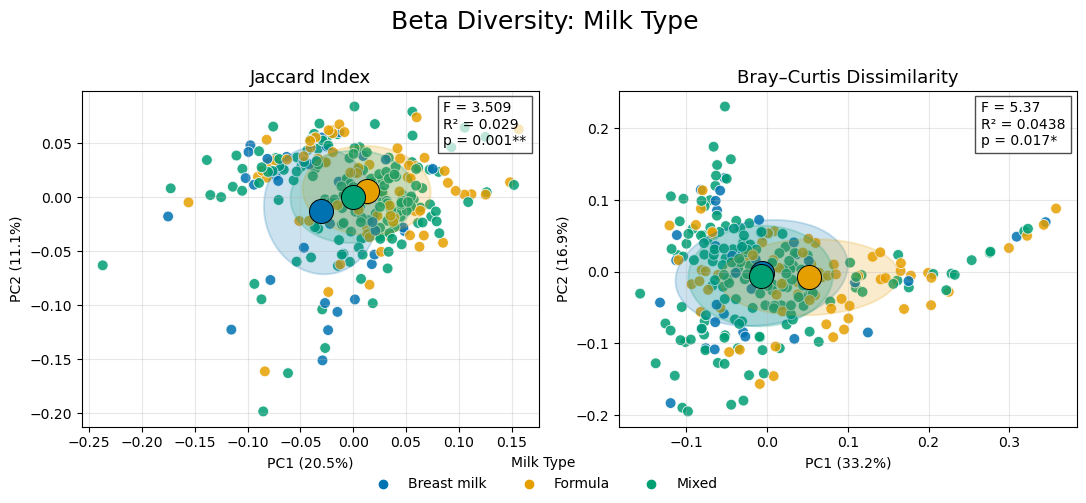

Saved figure to: ../data/processed/function_preds/pathways_results/diversity/plots/diet_weaning_PCoA_with_stats.png


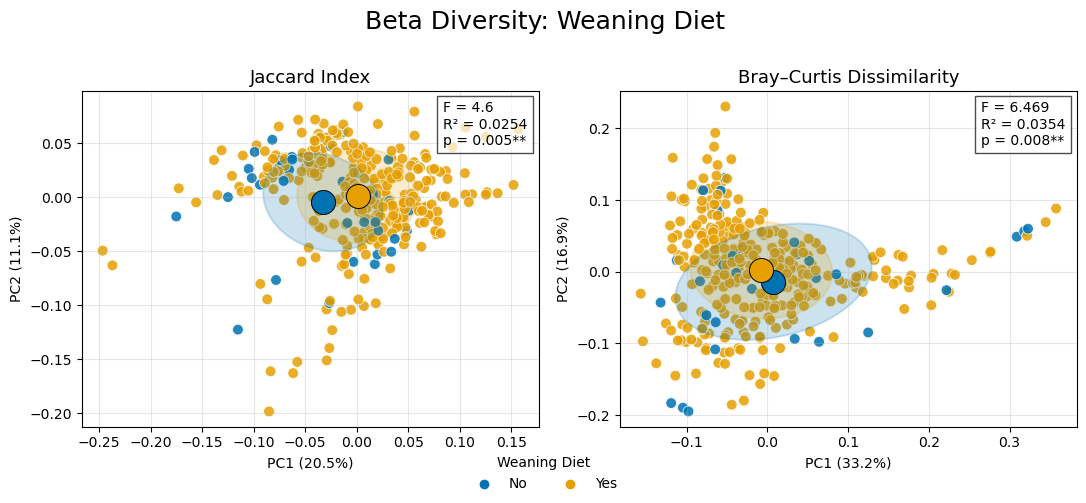

Saved figure to: ../data/processed/function_preds/pathways_results/diversity/plots/age_months_PCoA_with_stats.png


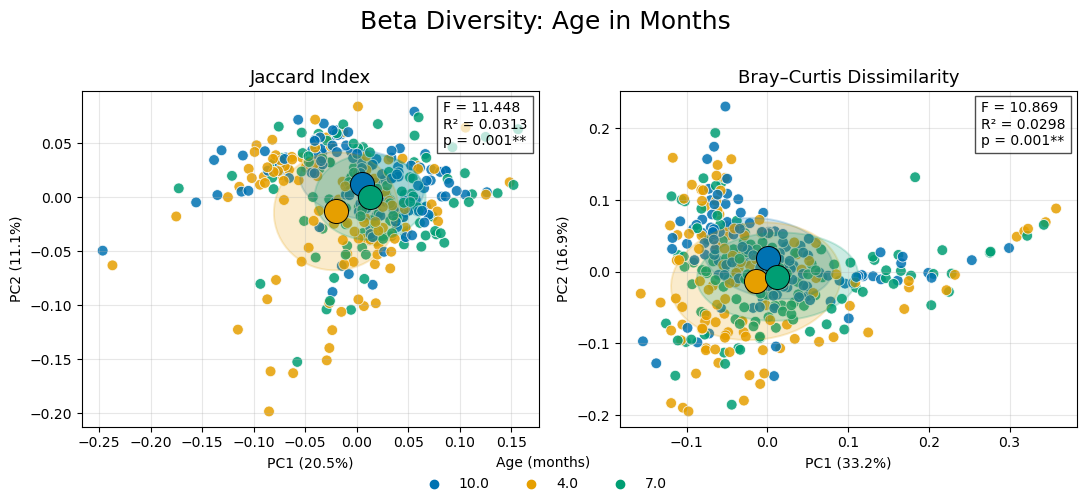

In [45]:
# Define cleaner and more descriptive labels for the beta diversity metrics
# These labels are used as titles in the PCoA subplots
metric_labels = {
    "Bray–Curtis": "Bray–Curtis Dissimilarity",
    "Jaccard": "Jaccard Index"
}

# Rename dictionary for milk type categories
# This improves readability of the plot legends
rename_milk = {
    "bd": "Breast milk",
    "fd": "Formula",
    "mixed": "Mixed"
}

# Rename dictionary for weaning categories
rename_weaning = {
    "yes": "Yes",
    "no": "No"
}

# Directory where the PCoA figures will be saved
export_dir = f"{beta_metrics_dir}/plots"
os.makedirs(export_dir, exist_ok=True)


# Create PCoA plots for diet_milk
plot_all_metrics_for_column_with_stats(
    column="diet_milk",
    rename_dict=rename_milk,
    metric_labels=metric_labels,
    legend_title="Milk Type",
    legend_position="lower center",
    figure_title="Beta Diversity: Milk Type",
    centroid_marker="o",
    export_dir=export_dir
)

# Create PCoA plots for diet_weaning
plot_all_metrics_for_column_with_stats(
    column="diet_weaning",
    rename_dict=rename_weaning,
    metric_labels=metric_labels,
    legend_title="Weaning Diet",
    legend_position="lower center",
    figure_title="Beta Diversity: Weaning Diet",
    centroid_marker="o",
    export_dir=export_dir
)

# Create PCoA plots for age_months
plot_all_metrics_for_column_with_stats(
    column="age_months",
    rename_dict=None, 
    metric_labels=metric_labels,
    legend_title="Age (months)",
    legend_position="lower center",
    figure_title="Beta Diversity: Age in Months",
    centroid_marker="o",
    export_dir=export_dir
)

Although PERMANOVA detects significant associations between functional beta diversity and variables such as age and diet, the PCoA plots do not show clear clustering or strong shifts in group centroids. This does not necessarily contradict the statistical results, as PERMANOVA can detect subtle but consistent differences that are not visually apparent in PCoA plots.

PERMANOVA tests differences across the full distance matrix and can identify small but consistent effects that explain only a limited proportion of the total variance, as reflected by the relatively low R² values. In contrast, PCoA visualizations show only the first two axes, which capture only part of the overall variation. Relevant differences may therefore be spread across higher dimensions and not be visually apparent.

In addition, strong inter-individual variability in the infant gut microbiome can dominate the ordination space and obscure gradual, group-level functional changes. Together, this suggests that age- and diet-associated functional shifts are subtle and continuous rather than forming distinct clusters, which is consistent with the PERMANOVA results.

#### Visualizing static variables across measurement points 
In this section, we visualize metadata variables that do not change within infants, including geo_location_name, delivery_mode, and treatment_exposure. For these variables, PERMANOVA was performed separately within each age group using one sample per infant. The PCoA plots allow us to examine whether differences in functional beta diversity associated with these static variables are visible within each age group and to compare these patterns with the age-stratified PERMANOVA results.

Saved figure to: ../data/processed/function_preds/pathways_results/diversity/plots/geo_location_name_PCoA_with_stats.png


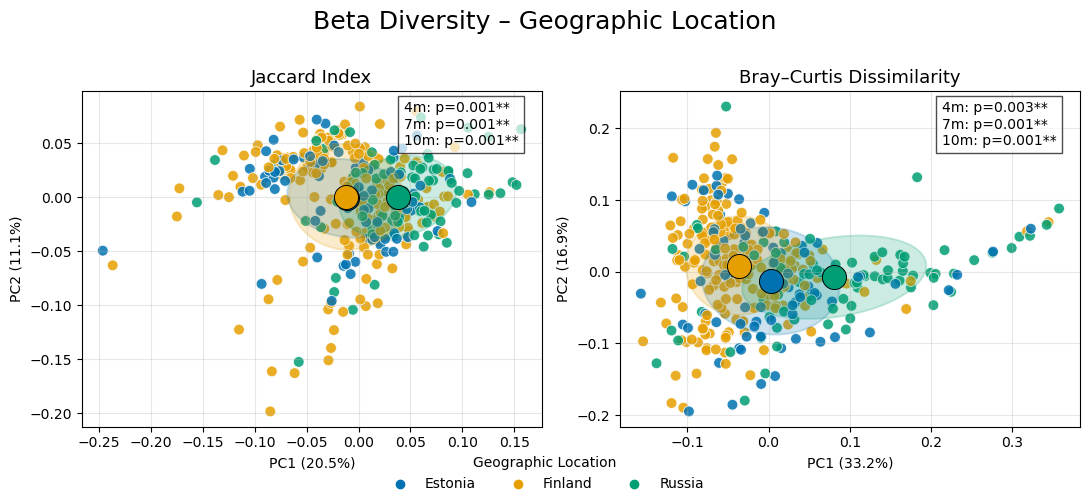

Saved figure to: ../data/processed/function_preds/pathways_results/diversity/plots/delivery_mode_PCoA_with_stats.png


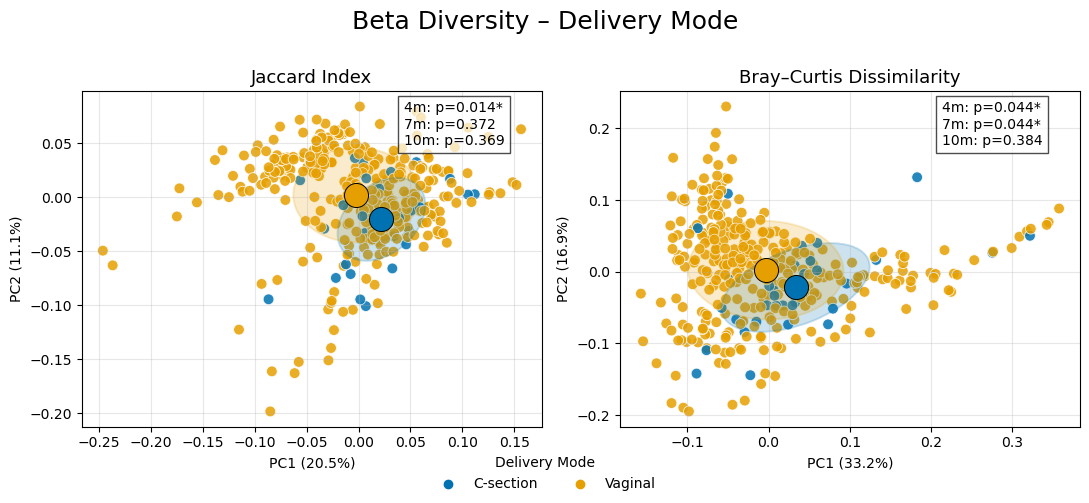

Saved figure to: ../data/processed/function_preds/pathways_results/diversity/plots/treatment_exposure_PCoA_with_stats.png


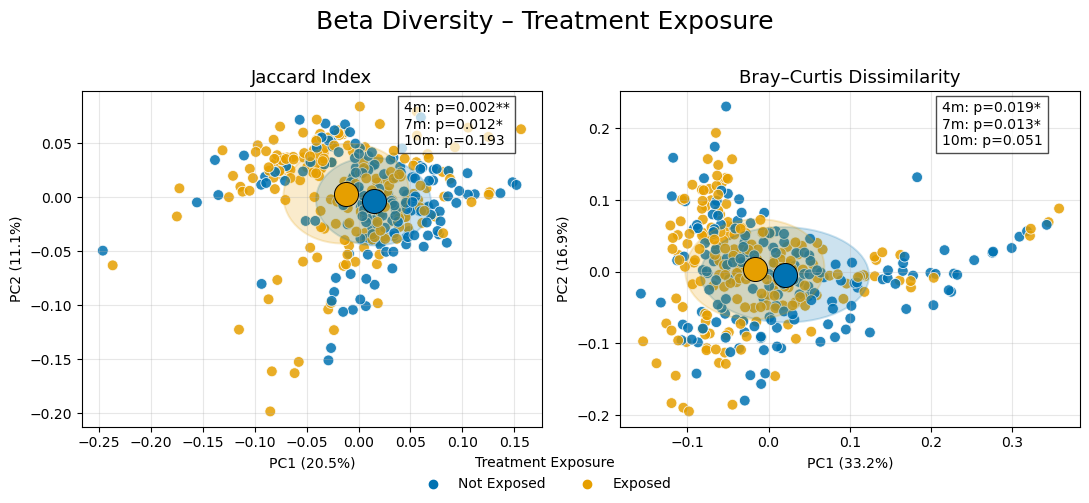

In [46]:
# Rename dictionaries for static metadata variables
# These make legend labels clearer and more readable in the plots

rename_geo = {
    "Finland": "Finland",
    "Estonia": "Estonia",
    "Russia": "Russia"
}

rename_delivery = {
    "vaginal": "Vaginal",
    "cesarean": "C-section"
}

rename_treatment = {
    "True": "Exposed",
    "False": "Not Exposed",
    True: "Exposed",
    False: "Not Exposed"
}

# Create PCoA plots for geographic location
plot_all_metrics_for_column_with_stats(
    column="geo_location_name",
    rename_dict=rename_geo,
    metric_labels=metric_labels,
    legend_title="Geographic Location",
    legend_position="lower center",
    figure_title="Beta Diversity – Geographic Location",
    centroid_marker="o",
    export_dir=export_dir,
    static=True
)

# Create PCoA plots for delivery mode
plot_all_metrics_for_column_with_stats(
    column="delivery_mode",
    rename_dict=rename_delivery,
    metric_labels=metric_labels,
    legend_title="Delivery Mode",
    legend_position="lower center",
    figure_title="Beta Diversity – Delivery Mode",
    centroid_marker="o",
    export_dir=export_dir,
    static=True
)

# Create PCoA plots for treatment exposure
plot_all_metrics_for_column_with_stats(
    column="treatment_exposure",
    rename_dict=rename_treatment,
    metric_labels=metric_labels,
    legend_title="Treatment Exposure",
    legend_position="lower center",
    figure_title="Beta Diversity – Treatment Exposure",
    centroid_marker="o",
    export_dir=export_dir,
    static=True
)

As in the previous section, although PERMANOVA detects significant associations between functional beta diversity and variables such as age and diet, the corresponding PCoA plots do not show strong clustering or pronounced shifts in centroids. This reflects small effect sizes, high inter-individual variability, and the fact that functional changes occur gradually across many dimensions, which are not fully captured by the first two PCoA axes.

However, in these plots, we do observe slightly larger shifts in centroids, particularly for Bray-Curtis dissimilarity when comparing geolocation groups. This aligns with the PERMANOVA results, where geolocation shows relatively higher R² values across all ages (around 0.1).

<div style="border: 2px solid #1f77b4; padding: 10px; border-radius: 6px; background-color: #eaf3fb;">
<b> Research questions the functional beta diversity analysis answers:</b>
    
- **How do the microbiome samples differ between different ages?**
    Age has a significant effect on the functional beta diversity of the infant gut microbiome across the entire study period. However, the effect size is relatively small, with age explaining approximately 3% of the total variation in functional community profiles ($R^2 \approx 0.03$). This suggests gradual, age-related functional shifts rather than strong clustering by age.

- **What differences do you see in terms of geolocation?**
    Functional beta diversity differs by geolocation across all ages for both distance metrics. Compared to other variables, geolocation shows higher R² values, explaining up to ~14% of the variation in functional profiles. This indicates that geographic location is associated with consistent differences in predicted functional composition, although it still explains only a small fraction of the total variability.
    
- **Did the treatment have an effect on the infant gut microbiome?**
    Treatment exposure only shows modest effects on functional beta diversity. At 4 and 7 months, there are significant associations for both Bray-Curtis and Jaccard metrics, but by 10 months, the effect is no longer significant. This implies that treatment may influence functional microbiome composition early on, but the impact fades over time. However, this interpretation is limited by the lack of detailed information on the type and timing of treatments.
</div>

### 4.4. Functional Differential Abundance Analysis
Because this notebook is already quite long, we decided to perform the functional differential abundance analysis in a separate notebook.

In the next notebook, we will use ANCOM-BC to test for differences in predicted pathway abundances across all metadata variables.

# References

Douglas, G.M., Maffei, V.J., Zaneveld, J.R. et al. PICRUSt2 for prediction of metagenome functions. Nat Biotechnol 38, 685–688 (2020). https://doi.org/10.1038/s41587-020-0548-6

Douglas, Gavin & Maffei, Vincent & Zaneveld, Jesse & Yurgel, Svetlana & Brown, James & Taylor, Christopher & Huttenhower, Curtis & Langille, Morgan. (2019). PICRUSt2: An improved and extensible approach for metagenome inference. 10.1101/672295. 

PICRUSt2 GitHub. https://github.com/picrust/picrust2/wiki/

Q2 picrust2 Tutorial. (2023). GitHub. https://github.com/picrust/picrust2/wiki/q2-picrust2-Tutorial

Oksanen, J., Blanchet, F. G., Friendly, M., Kindt, R., Legendre, P., McGlinn, D., Minchin, P. R., O’Hara, R. B., Simpson, G. L., Solymos, P., Stevens, M. H. H., Szoecs, E., & Wagner, H. (2025). adonis2: Permutational Multivariate Analysis of Variance Using Distance Matrices. In *vegan: Community Ecology Package*. CRAN. https://search.r-project.org/CRAN/refmans/vegan/html/adonis.html 
